# 02. TF-IDF Model Testing & Evaluation

**Goal:**  
Evaluate the generalization performance of the TF-IDF Naive Bayes pipeline on validation data.

**Pipeline Overview:**
1. **Load Artifacts:** Ingest `tfidf_vectorizer.pkl` and `tfidf_naive_bayes_model.pkl` from `models/tfidf_version/`.
2. **Transform:** Apply `.transform()` strictly on `data/processed/val_cleaned.csv`.
3. **Inference & Metrics:** Generate predictions and output the metrics report + confusion heatmap.

In [1]:
import sys
import os
import pickle
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath("../../src"))

from preprocessing import transform_new_data
from naive_bayes import MultinomialNaiveBayes
from metrics import compute_classification_metrics, plot_confusion_matrix

# 1. Load Validation Data
df_val = pd.read_csv("../../data/processed/validation_cleaned.csv").dropna(subset=['tweet_content'])
X_val_text = df_val['tweet_content']
y_true = df_val['sentiment'].values

# 2. Load TF-IDF Artifacts
tfidf_dir = "../../models/Tf-Idf version"

with open(os.path.join(tfidf_dir, "tfidf_vectorizer.pkl"), "rb") as f:
    vectorizer = pickle.load(f)

model = MultinomialNaiveBayes.load_model(os.path.join(tfidf_dir, "tfidf_naive_bayes_model.pkl"))

print(f"Loaded TF-IDF Vectorizer (Vocab Size: {len(vectorizer.vocabulary_)})")
print(f"Loaded Model Classes: {model.classes_}")

Loaded TF-IDF Vectorizer (Vocab Size: 20086)
Loaded Model Classes: ['Negative' 'Neutral' 'Positive']


## 2. Strict Transformation & Inference

We map validation features into the TF-IDF matrix space without re-fitting.

In [2]:
# Transform validation text
X_val_sparse = transform_new_data(vectorizer, X_val_text)

# Run Inference
y_pred = model.predict(X_val_sparse)

print(f"Validation Feature Matrix Shape: {X_val_sparse.shape}")
print("\nSample Predictions vs Ground Truth:")
for i in range(10):
    print(f"Predicted: {y_pred[i]:<10} | Actual: {y_true[i]}")

Validation Feature Matrix Shape: (827, 20086)

Sample Predictions vs Ground Truth:
Predicted: Neutral    | Actual: Neutral
Predicted: Negative   | Actual: Negative
Predicted: Negative   | Actual: Negative
Predicted: Neutral    | Actual: Neutral
Predicted: Negative   | Actual: Negative
Predicted: Positive   | Actual: Positive
Predicted: Positive   | Actual: Positive
Predicted: Positive   | Actual: Positive
Predicted: Negative   | Actual: Negative
Predicted: Positive   | Actual: Positive


## 3. Performance Metrics & Heatmap Export

Evaluation report and confusion matrix visualization saved directly to `models/Tf-Idf version/`.

TF-IDF ACCURACY:  0.8368
TF-IDF MACRO F1:  0.8362

--- PER-CLASS METRICS ---
Class: Negative   | Precision: 0.7952 | Recall: 0.8759 | F1: 0.8336
Class: Neutral    | Precision: 0.8811 | Recall: 0.7544 | F1: 0.8129
Class: Positive   | Precision: 0.8414 | Recall: 0.8841 | F1: 0.8622


Visualized confusion matrix saved to ../../models/Tf-Idf version\tfidf_confusion_matrix.png


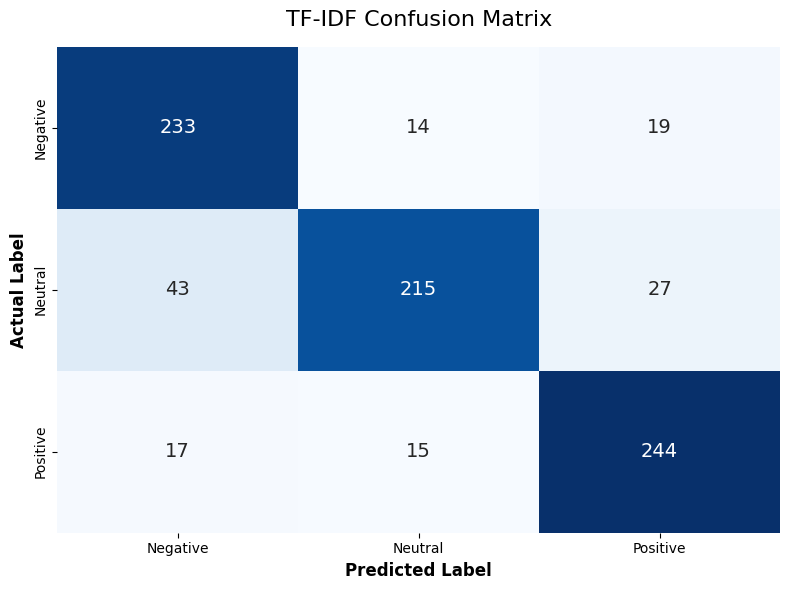

In [3]:
# Calculate custom metrics
results = compute_classification_metrics(y_true, y_pred, classes=model.classes_)

# 1. Print Summary
print("="*40)
print(f"TF-IDF ACCURACY:  {results['accuracy']:.4f}")
print(f"TF-IDF MACRO F1:  {results['macro']['macro_f1']:.4f}")
print("="*40)

# 2. Per-Class Breakdown
print("\n--- PER-CLASS METRICS ---")
for c in results['classes']:
    m = results['per_class'][c]
    print(f"Class: {c:<10} | Precision: {m['precision']:.4f} | Recall: {m['recall']:.4f} | F1: {m['f1_score']:.4f}")

# 3. Save Confusion Matrix Heatmap
plot_confusion_matrix(
    cm=results['confusion_matrix'],
    classes=results['classes'],
    title="TF-IDF Confusion Matrix",
    save_path=os.path.join(tfidf_dir, "tfidf_confusion_matrix.png")
)

## TF-IDF Experiment vs. Hard Cutoff Baseline

### Performance Comparison
Testing continuous TF-IDF weighting (`max_df=0.50`) yielded strong metrics overall but fell slightly behind the hard-cutoff `CountVectorizer` baseline (`max_df=0.10`):

| Metric | CountVectorizer (`max_df=0.10`) | TF-IDF (`max_df=0.50`) | Net Difference |
| :--- | :--- | :--- | :--- |
| **Overall Accuracy** | **84.04%** | 83.68% | -0.36% |
| **Macro F1-Score** | **84.01%** | 83.62% | -0.39% |
| **Neutral F1** | **82.81%** | 81.29% | -1.52% |
| **Positive F1** | 85.37% | **86.22%** | **+0.85%** |
| **Negative F1** | **83.86%** | 83.36% | -0.50% |

---

### Key Tradeoffs & Architectural Insights

* **Neutral Bleed Re-emerged:** Correct Neutral predictions dropped from 224 to 215, while Neutral-to-Negative errors rose from 32 to 43. Because TF-IDF scales down entity names without eliminating them completely, residual domain noise still leaked into short tweets.
* **Positive Precision Lift:** TF-IDF achieved the highest Positive F1 score (**86.22%**) and Precision (**84.14%**). Inverse document frequency strongly amplifies rare, expressive sentiment adjectives (e.g., *"flawless"*, *"masterpiece"*).
* **Final Verdict:** The continuous scaling of TF-IDF is mathematically elegant, but the blunt, hard-thresholding of `CountVectorizer` (`max_df=0.10`) remains the optimal pipeline for Multinomial Naive Bayes on this dataset.